# 05. NaN 처리 전략 비교 실험
- 03_feature_engineering.ipynb 완료 후 실행
- nan_strategies.py의 함수를 import해서 실험

| 실험 | offspeed_zero | drop_threshold | 설명 |
|---|---|---|---|
| E2-1 | False | None | 베이스라인 (모델 내부 처리) |
| E2-2 | True | None | 미등판 구종 delta → 0 |
| E2-3 | False | 0.5 | NaN 50%↑ 컬럼 제거 |
| E2-4 | False | 0.3 | NaN 30%↑ 컬럼 제거 |
| E2-5 | True | 0.5 | E2-2 + E2-3 조합 |

---

## 실험 결과 요약

| 전략 | feature 수 | XGB Val RMSE | XGB Val R² | CB Val RMSE | CB Val R² |
|---|---|---|---|---|---|
| E2-1 baseline | 59 | 0.1362 | 0.0074 | 0.1362 | 0.0069 |
| E2-2 zero | 59 | 0.1363 | 0.0051 | 0.1361 | **0.0084** |
| E2-3 drop50 | 54 | 0.1363 | 0.0063 | 0.1361 | 0.0081 |
| E2-4 drop30 | 28 | 0.1362 | 0.0068 | 0.1361 | **0.0085** |
| E2-5 zero+drop50 | 59 | 0.1363 | 0.0051 | 0.1361 | 0.0084 |

### 최적 전략 확정

| 모델 | 최적 전략 | 근거 |
|---|---|---|
| XGBoost | **E2-1 baseline** | Val RMSE 최소 |
| CatBoost | **E2-4 drop30** | Val R² 최고 |

> **결론**: 5가지 전략 간 성능 차이가 미미함 (RMSE 소수점 4자리 차이).  
> 도메인 논리 상 모델 내부 처리(E2-1)를 기본값으로 유지하되, 이후 실험은 베이스라인(E2-1) 기준으로 진행.

In [1]:
# ── 환경 감지 ──────────────────────────────────────────────
import os, sys

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE = '/content/drive/MyDrive/투수 컨디션 예측 ML'
    NB_DIR = os.path.join(DRIVE, '3_modeling')
    sys.path.insert(0, NB_DIR)
else:
    DRIVE  = os.path.dirname(os.path.abspath('__file__'))
    NB_DIR = os.path.dirname(os.path.abspath('__file__'))

FEAT_PATH  = os.path.join(DRIVE, '0_data', '4_features', 'features_batter9.parquet')
OUTPUT_DIR = os.path.join(DRIVE, '4_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'환경: {"코랩" if IN_COLAB else "로컬"}')
print(f'FEAT_PATH : {FEAT_PATH}')

Mounted at /content/drive
환경: 코랩
FEAT_PATH : /content/drive/MyDrive/투수 컨디션 예측 ML/0_data/4_features/features_batter9.parquet


In [2]:
# ── 패키지 설치 ────────────────────────────────────────────
try:
    import xgboost
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'xgboost', '-q'])

try:
    import catboost
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'catboost', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import nan_strategies as ns
importlib.reload(ns)  # 코랩에서 수정 후 재로드용

print('nan_strategies 로드 완료')

nan_strategies 로드 완료


## 1. 데이터 결측 현황 확인

In [3]:
df = pd.read_parquet(FEAT_PATH)
meta = ['game_pk', 'pitcher', 'season', 'y_woba']
feat_cols = [c for c in df.columns if c not in meta]

nan_df = pd.DataFrame({
    'col': feat_cols,
    'nan_rate': [df[c].isna().mean() for c in feat_cols]
}).sort_values('nan_rate', ascending=False)

print(f'전체 feature 수: {len(feat_cols)}')
print(f'NaN 30%↑ 컬럼 수: {(nan_df.nan_rate >= 0.3).sum()}')
print(f'NaN 50%↑ 컬럼 수: {(nan_df.nan_rate >= 0.5).sum()}')
print()
print(nan_df[nan_df.nan_rate > 0].to_string(index=False))

전체 feature 수: 59
NaN 30%↑ 컬럼 수: 31
NaN 50%↑ 컬럼 수: 5

                 col  nan_rate
 delta_spin_Offspeed  0.548291
  delta_ext_Offspeed  0.547254
delta_speed_Offspeed  0.546865
delta_pos_x_Offspeed  0.546865
delta_pos_z_Offspeed  0.546865
 delta_spin_Breaking  0.467266
  delta_ext_Breaking  0.466531
delta_speed_Breaking  0.466056
delta_pos_x_Breaking  0.466056
delta_pos_z_Breaking  0.466056
  std_speed_Offspeed  0.432004
   prev_ext_Offspeed  0.411996
  prev_spin_Offspeed  0.411996
 prev_pos_z_Offspeed  0.411996
 prev_pos_x_Offspeed  0.411996
 prev_speed_Offspeed  0.411996
 prev_pos_x_Breaking  0.401495
  prev_spin_Breaking  0.401495
 prev_speed_Breaking  0.401495
 prev_pos_z_Breaking  0.401495
   prev_ext_Breaking  0.401495
 delta_spin_Fastball  0.352794
  delta_ext_Fastball  0.351973
 prev_speed_Fastball  0.351454
   prev_ext_Fastball  0.351454
 prev_pos_z_Fastball  0.351454
  prev_spin_Fastball  0.351454
delta_pos_x_Fastball  0.351454
delta_speed_Fastball  0.351454
delta_pos_z_Fastb

## 2. 전체 실험 실행

In [4]:
summary = ns.run_all(FEAT_PATH)
summary

[E2-1 baseline] 실행 중...
  XGB Val RMSE=0.1362  R²=0.0074
  CB  Val RMSE=0.1362  R²=0.0069
[E2-2 zero] 실행 중...
  XGB Val RMSE=0.1363  R²=0.0051
  CB  Val RMSE=0.1361  R²=0.0084
[E2-3 drop50] 실행 중...
  XGB Val RMSE=0.1363  R²=0.0063
  CB  Val RMSE=0.1361  R²=0.0081
[E2-4 drop30] 실행 중...
  XGB Val RMSE=0.1362  R²=0.0068
  CB  Val RMSE=0.1361  R²=0.0085
[E2-5 zero+drop50] 실행 중...
  XGB Val RMSE=0.1363  R²=0.0051
  CB  Val RMSE=0.1361  R²=0.0084


,offspeed_zero,drop_threshold,n_features,dropped_cols,xgb_train_rmse,xgb_train_r2,xgb_val_rmse,xgb_val_r2,xgb_test_rmse,xgb_test_r2,cb_train_rmse,cb_train_r2,cb_val_rmse,cb_val_r2,cb_test_rmse,cb_test_r2,name
0,False,NaN,59,[],0.131942,0.093037,0.136177,0.007407,0.137434,-0.004318,0.135126,0.048730,0.136213,0.006891,0.136896,0.003533,E2-1 baseline
1,True,NaN,59,[],0.135768,0.039670,0.136339,0.005053,0.137218,-0.001161,0.133610,0.069956,0.136106,0.008449,0.137070,0.000993,E2-2 zero
2,False,0.5,54,"[delta_speed_Offspeed, delta_spin_Offspeed, de...",0.132409,0.086597,0.136253,0.006300,0.136912,0.003292,0.133950,0.065209,0.136127,0.008142,0.137039,0.001445,E2-3 drop50
3,False,0.3,28,"[std_speed_Offspeed, prev_speed_Fastball, prev...",0.134246,0.061081,0.136216,0.006847,0.137194,-0.000818,0.136348,0.031447,0.136105,0.008454,0.136883,0.003717,E2-4 drop30
4,True,0.5,59,[],0.135768,0.039670,0.136339,0.005053,0.137218,-0.001161,0.133610,0.069956,0.136106,0.008449,0.137070,0.000993,E2-5 zero+drop50


## 3. 결과 비교 테이블

In [5]:
cols = ['name', 'n_features',
        'xgb_val_rmse', 'xgb_val_r2',
        'cb_val_rmse',  'cb_val_r2',
        'xgb_test_rmse', 'xgb_test_r2',
        'cb_test_rmse',  'cb_test_r2']

result_table = summary[cols].copy()
result_table = result_table.round(4)
print(result_table.to_string(index=False))

            name  n_features  xgb_val_rmse  xgb_val_r2  cb_val_rmse  cb_val_r2  xgb_test_rmse  xgb_test_r2  cb_test_rmse  cb_test_r2
   E2-1 baseline          59        0.1362      0.0074       0.1362     0.0069         0.1374      -0.0043        0.1369      0.0035
       E2-2 zero          59        0.1363      0.0051       0.1361     0.0084         0.1372      -0.0012        0.1371      0.0010
     E2-3 drop50          54        0.1363      0.0063       0.1361     0.0081         0.1369       0.0033        0.1370      0.0014
     E2-4 drop30          28        0.1362      0.0068       0.1361     0.0085         0.1372      -0.0008        0.1369      0.0037
E2-5 zero+drop50          59        0.1363      0.0051       0.1361     0.0084         0.1372      -0.0012        0.1371      0.0010


## 4. Val RMSE 시각화

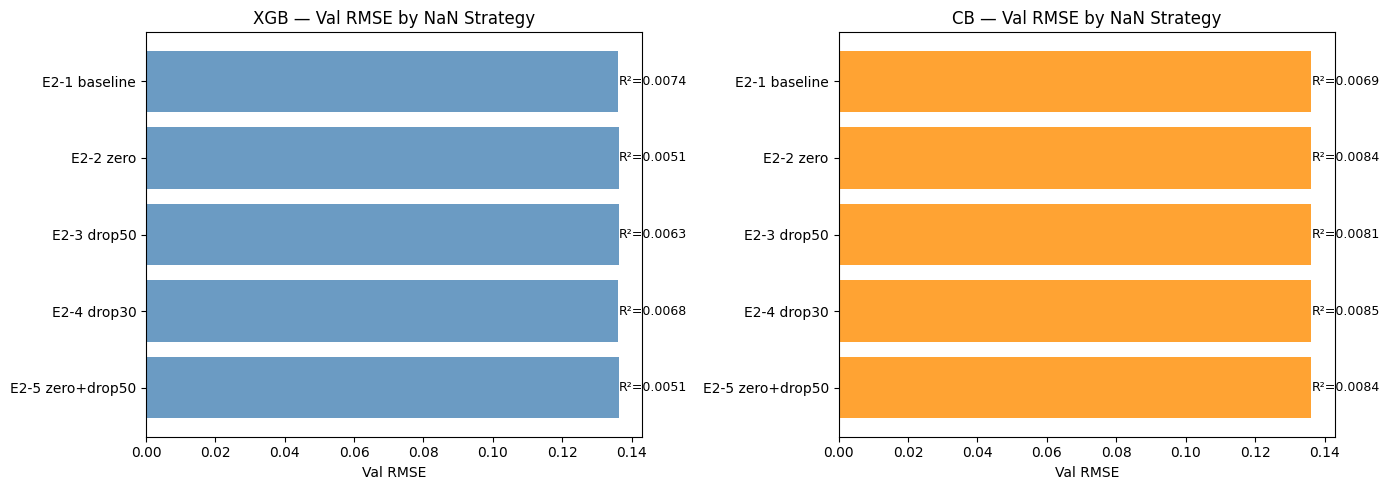

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, color in zip(axes, ['xgb', 'cb'], ['steelblue', 'darkorange']):
    rmse_col = f'{model}_val_rmse'
    r2_col   = f'{model}_val_r2'
    names    = summary['name']
    rmses    = summary[rmse_col]

    bars = ax.barh(names, rmses, color=color, alpha=0.8)
    ax.set_xlabel('Val RMSE')
    ax.set_title(f'{model.upper()} — Val RMSE by NaN Strategy')
    ax.invert_yaxis()

    for bar, r2 in zip(bars, summary[r2_col]):
        ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
                f'R²={r2:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. 결론 및 최적 전략 확정

In [7]:
# Val RMSE 기준 최적 전략 자동 선택
best_xgb = summary.loc[summary['xgb_val_rmse'].idxmin(), 'name']
best_cb  = summary.loc[summary['cb_val_rmse'].idxmin(), 'name']

print(f'XGBoost 최적 전략: {best_xgb}')
print(f'CatBoost 최적 전략: {best_cb}')
print()
print('→ 이후 실험(X구간, 이상치, 튜닝)에서 사용할 NaN 전략 확정')

XGBoost 최적 전략: E2-1 baseline
CatBoost 최적 전략: E2-4 drop30

→ 이후 실험(X구간, 이상치, 튜닝)에서 사용할 NaN 전략 확정


In [8]:
# 결과 저장
out = os.path.join(OUTPUT_DIR, 'nan_experiment_results.csv')
summary[cols].to_csv(out, index=False)
print(f'저장 완료 → {out}')

저장 완료 → /content/drive/MyDrive/투수 컨디션 예측 ML/4_output/nan_experiment_results.csv
